# Washington DC Office and Multifamily Stock Analysis

This notebook searches ComStock office buildings and ResStock multifamily dwelling units in Washington, DC, compares stock characteristics, downloads a few of the most energy-intensive records, plots demand and monthly end-use profiles, and generates measure recommendations from the observed energy drivers.

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from comstock_processor import ComStockProcessor
from resstock_processor import ResStockProcessor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None

STATE = "DC"
UPGRADE = "0"
EUI_COL = "out.site_energy.total.energy_consumption_intensity..kwh_per_ft2"
SQFT_COL = "in.sqft..ft2"
TOTAL_SITE_COL = "out.site_energy.total.energy_consumption..kwh"

dataset_dir = Path.cwd() / "datasets"
comstock_dir = dataset_dir / "comstock" / "dc_stock_analysis"
resstock_dir = dataset_dir / "resstock" / "dc_stock_analysis"
base_dir = dataset_dir / "dc_stock_analysis"
comstock_ts_dir = comstock_dir / "time_series"
resstock_ts_dir = resstock_dir / "time_series"
figures_dir = Path.cwd() / "figures" / "dc_stock_analysis"

for path in [comstock_dir, resstock_dir, comstock_ts_dir, resstock_ts_dir, figures_dir]:
    path.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
print(f"Working directory: {base_dir}")

Working directory: /Users/nlong/working/comstock/comstock-processor/datasets/dc_stock_analysis


## Search Washington, DC Stock

ComStock represents commercial buildings, so the office search combines `SmallOffice`, `MediumOffice`, and `LargeOffice`. ResStock represents residential dwelling units, so the multifamily search combines the two multifamily housing categories.

In [2]:
def load_comstock_offices() -> pd.DataFrame:
    frames = []
    for building_type in ["SmallOffice", "MediumOffice", "LargeOffice"]:
        processor = ComStockProcessor(
            state=STATE,
            county_name="All",
            building_type=building_type,
            upgrade=UPGRADE,
            base_dir=comstock_dir,
        )
        frame = processor.process_metadata(save_dir=comstock_dir).copy()
        frame["stock"] = "ComStock"
        frame["search_group"] = "Office"
        frame["building_category"] = frame["in.comstock_building_type"]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


def load_resstock_multifamily() -> pd.DataFrame:
    frames = []
    for building_type in ["Multi-Family with 2 - 4 Units", "Multi-Family with 5+ Units"]:
        processor = ResStockProcessor(
            state=STATE,
            county_name="All",
            building_type=building_type,
            upgrade=UPGRADE,
            base_dir=resstock_dir,
        )
        frame = processor.process_metadata(save_dir=resstock_dir).copy()
        frame["stock"] = "ResStock"
        frame["search_group"] = "Multifamily"
        frame["building_category"] = frame["in.geometry_building_type_recs"]
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)


office_df = load_comstock_offices()
multifamily_df = load_resstock_multifamily()
stock_df = pd.concat([office_df, multifamily_df], ignore_index=True)

stock_df[EUI_COL] = pd.to_numeric(stock_df[EUI_COL], errors="coerce")
stock_df[SQFT_COL] = pd.to_numeric(stock_df[SQFT_COL], errors="coerce")

summary_cols = ["stock", "search_group", "building_category", "bldg_id", "in.state", "in.county_name", SQFT_COL, EUI_COL]
display(stock_df[summary_cols].head())
print(f"Office records: {len(office_df):,}")
print(f"Multifamily records: {len(multifamily_df):,}")

Metadata csv already exists. Skipping creation. Delete /Users/nlong/working/comstock/comstock-processor/datasets/comstock/dc_stock_analysis/release_3-DC-All-SmallOffice-All-0-selected_metadata.csv if you want to save again.


/Users/nlong/working/comstock/comstock-processor/comstock_processor.py:183: DtypeWarning: Columns (0: in.economizer_damper_stuck_fault_timing) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(output_csv)


Metadata csv already exists. Skipping creation. Delete /Users/nlong/working/comstock/comstock-processor/datasets/comstock/dc_stock_analysis/release_3-DC-All-MediumOffice-All-0-selected_metadata.csv if you want to save again.
Metadata csv already exists. Skipping creation. Delete /Users/nlong/working/comstock/comstock-processor/datasets/comstock/dc_stock_analysis/release_3-DC-All-LargeOffice-All-0-selected_metadata.csv if you want to save again.


Metadata csv already exists. Skipping creation. Delete /Users/nlong/working/comstock/comstock-processor/datasets/resstock/dc_stock_analysis/release_1-DC-All-Multi-Family with 2 - 4 Units-All-0-selected_metadata.csv if you want to save again.
Metadata csv already exists. Skipping creation. Delete /Users/nlong/working/comstock/comstock-processor/datasets/resstock/dc_stock_analysis/release_1-DC-All-Multi-Family with 5+ Units-All-0-selected_metadata.csv if you want to save again.


/Users/nlong/working/comstock/comstock-processor/comstock_processor.py:183: DtypeWarning: Columns (0: in.number_stories) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(output_csv)


,stock,search_group,building_category,bldg_id,in.state,in.county_name,in.sqft..ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2
0,ComStock,Office,SmallOffice,541,DC,"DC, District of Columbia",2000.0,16.504167
1,ComStock,Office,SmallOffice,541,DC,"DC, District of Columbia",2000.0,16.504167
2,ComStock,Office,SmallOffice,541,DC,"DC, District of Columbia",2000.0,16.504167
3,ComStock,Office,SmallOffice,541,DC,"DC, District of Columbia",2000.0,16.504167
4,ComStock,Office,SmallOffice,541,DC,"DC, District of Columbia",2000.0,16.504167


Office records: 8,451
Multifamily records: 799


## Stock Characteristics

The first plots compare how many records are available by category, how floor area relates to site-energy intensity, and how the high-energy tail differs between office buildings and multifamily units.

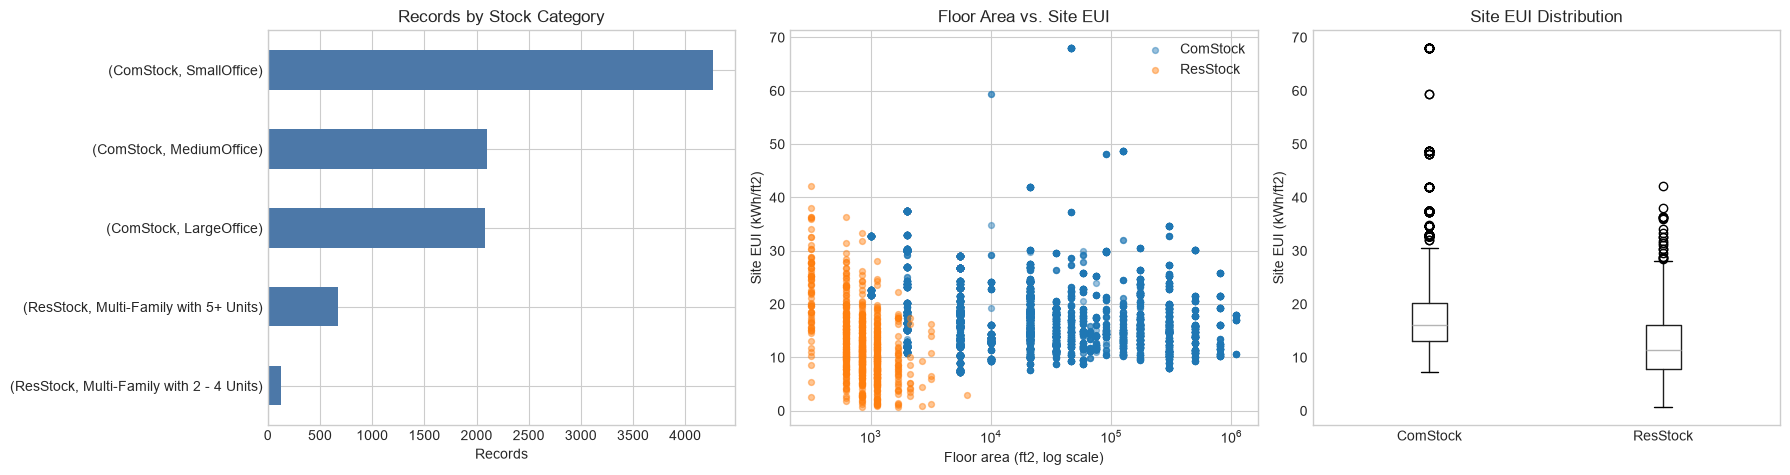

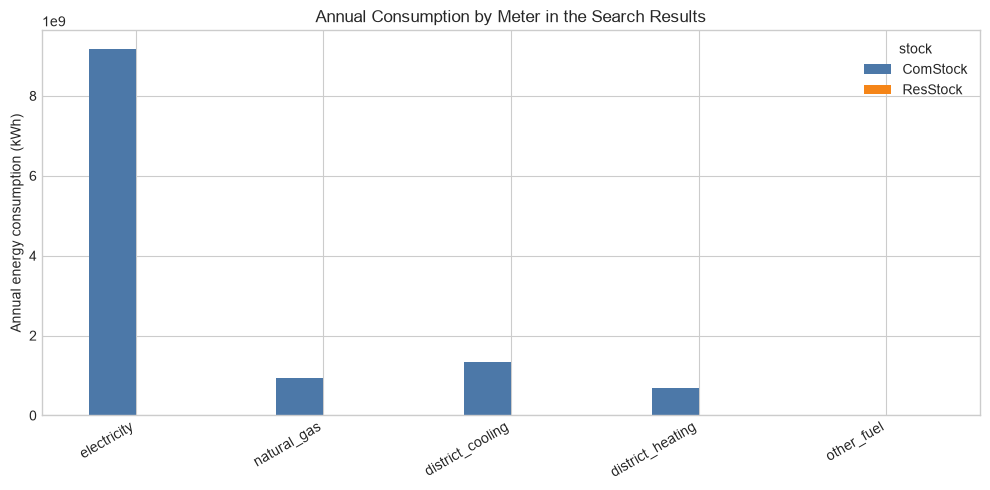

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

category_counts = stock_df.groupby(["stock", "building_category"]).size().sort_values()
category_counts.plot(kind="barh", ax=axes[0], color="#4c78a8")
axes[0].set_title("Records by Stock Category")
axes[0].set_xlabel("Records")
axes[0].set_ylabel("")

for stock_name, frame in stock_df.groupby("stock"):
    axes[1].scatter(frame[SQFT_COL], frame[EUI_COL], s=18, alpha=0.45, label=stock_name)
axes[1].set_xscale("log")
axes[1].set_title("Floor Area vs. Site EUI")
axes[1].set_xlabel("Floor area (ft2, log scale)")
axes[1].set_ylabel("Site EUI (kWh/ft2)")
axes[1].legend()

stock_df.boxplot(column=EUI_COL, by="stock", ax=axes[2], grid=False)
axes[2].set_title("Site EUI Distribution")
axes[2].set_xlabel("")
axes[2].set_ylabel("Site EUI (kWh/ft2)")
fig.suptitle("")
fig.tight_layout()
plt.show()

annual_meter_cols = [
    "out.electricity.total.energy_consumption..kwh",
    "out.natural_gas.total.energy_consumption..kwh",
    "out.district_cooling.total.energy_consumption..kwh",
    "out.district_heating.total.energy_consumption..kwh",
    "out.other_fuel.total.energy_consumption..kwh",
]
available_meter_cols = [col for col in annual_meter_cols if col in stock_df.columns]
annual_meters = stock_df.groupby("stock")[available_meter_cols].sum().T
annual_meters.index = annual_meters.index.str.replace("out.", "", regex=False).str.replace(
    ".total.energy_consumption..kwh", "", regex=False
)
annual_meters.plot(kind="bar", figsize=(10, 5), color=["#4c78a8", "#f58518"])
plt.title("Annual Consumption by Meter in the Search Results")
plt.ylabel("Annual energy consumption (kWh)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Select and Download High-Intensity Records

The next cell selects the three highest-site-EUI records from each stock dataset. These are intentionally small downloads so the workflow is easy to run while still showing building-level time-series analysis.

In [4]:
def top_intensive(frame: pd.DataFrame, stock_name: str, n: int = 3) -> pd.DataFrame:
    return (
        frame.dropna(subset=[EUI_COL])
        .sort_values(EUI_COL, ascending=False)
        .head(n)
        .assign(stock=stock_name)
    )


selected_offices = top_intensive(office_df, "ComStock")
selected_multifamily = top_intensive(multifamily_df, "ResStock")
selected_offices["bldg_id"] = selected_offices["bldg_id"].astype(str)
selected_multifamily["bldg_id"] = selected_multifamily["bldg_id"].astype(str)
selected = pd.concat([selected_offices, selected_multifamily], ignore_index=True)

selected_display_cols = ["stock", "search_group", "building_category", "bldg_id", SQFT_COL, EUI_COL, TOTAL_SITE_COL]
selected_display_cols = [col for col in selected_display_cols if col in selected.columns]
display(selected[selected_display_cols])

,stock,search_group,building_category,bldg_id,in.sqft..ft2,out.site_energy.total.energy_consumption_intensity..kwh_per_ft2,out.site_energy.total.energy_consumption..kwh
0,ComStock,Office,LargeOffice,17353,46000.0,67.945290,3.125483e+06
1,ComStock,Office,LargeOffice,17353,46000.0,67.945290,3.125483e+06
2,ComStock,Office,LargeOffice,17353,46000.0,67.945290,3.125483e+06
3,ResStock,Multifamily,Multi-Family with 2 - 4 Units,456301,322.0,42.224988,1.359645e+04
4,ResStock,Multifamily,Multi-Family with 5+ Units,193877,322.0,37.942692,1.221755e+04
5,ResStock,Multifamily,Multi-Family with 2 - 4 Units,85483,322.0,36.422727,1.172812e+04


In [5]:
comstock_download_processor = ComStockProcessor(
    state=STATE, county_name="All", building_type="All", upgrade=UPGRADE, base_dir=comstock_dir
)
resstock_download_processor = ResStockProcessor(
    state=STATE, county_name="All", building_type="All", upgrade=UPGRADE, base_dir=resstock_dir
)

comstock_paths, comstock_ids = comstock_download_processor.process_building_time_series(selected_offices, save_dir=comstock_ts_dir)
resstock_paths, resstock_ids = resstock_download_processor.process_building_time_series(selected_multifamily, save_dir=resstock_ts_dir)

downloads = pd.DataFrame(
    {
        "stock": ["ComStock"] * len(comstock_paths) + ["ResStock"] * len(resstock_paths),
        "bldg_id": comstock_ids + resstock_ids,
        "path": [str(path) for path in comstock_paths + resstock_paths],
    }
)
display(downloads)

Number of workers: 16


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 34192.70it/s]

Number of workers: 16


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:00<00:00, 83886.08it/s]

,stock,bldg_id,path
0,ComStock,17353,/Users/nlong/working/comstock/comstock-process...
1,ComStock,17353,/Users/nlong/working/comstock/comstock-process...
2,ComStock,17353,/Users/nlong/working/comstock/comstock-process...
3,ResStock,456301,/Users/nlong/working/comstock/comstock-process...
4,ResStock,193877,/Users/nlong/working/comstock/comstock-process...
5,ResStock,85483,/Users/nlong/working/comstock/comstock-process...


## Demand Profiles and Monthly End Uses

The time-series files contain interval energy consumption columns. The demand plot treats interval electricity consumption as a demand proxy; when the source interval is hourly, the units read directly as average kW for that hour.

In [6]:
def read_time_series(paths: list[Path], building_ids: list[str], stock_name: str) -> pd.DataFrame:
    frames = []
    for path, building_id in zip(paths, building_ids):
        frame = pd.read_parquet(path)
        frame["timestamp"] = pd.to_datetime(frame["timestamp"])
        frame["bldg_id"] = str(building_id)
        frame["stock"] = stock_name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


ts_df = pd.concat(
    [
        read_time_series(comstock_paths, comstock_ids, "ComStock"),
        read_time_series(resstock_paths, resstock_ids, "ResStock"),
    ],
    ignore_index=True,
)

energy_cols = [col for col in ts_df.columns if col.startswith("out.") and col.endswith(".energy_consumption")]
print(f"Loaded {len(ts_df):,} time-series rows and {len(energy_cols)} energy columns.")
display(ts_df[["stock", "bldg_id", "timestamp", *energy_cols[:5]]].head())

Loaded 210,240 time-series rows and 31 energy columns.


,stock,bldg_id,timestamp,out.district_cooling.cooling.energy_consumption,out.district_heating.heating.energy_consumption,out.district_heating.water_systems.energy_consumption,out.electricity.cooling.energy_consumption,out.electricity.exterior_lighting.energy_consumption
0,ComStock,17353,2018-01-01 00:15:00,21.280193,78.443245,0.075653,0.0,0.90183
1,ComStock,17353,2018-01-01 00:30:00,21.378826,78.886635,0.457771,0.0,0.90183
2,ComStock,17353,2018-01-01 00:45:00,21.474634,79.124237,0.526454,0.0,0.90183
3,ComStock,17353,2018-01-01 01:00:00,21.543056,79.565620,0.000000,0.0,0.90183
4,ComStock,17353,2018-01-01 01:15:00,21.537939,79.549988,0.000000,0.0,0.90183


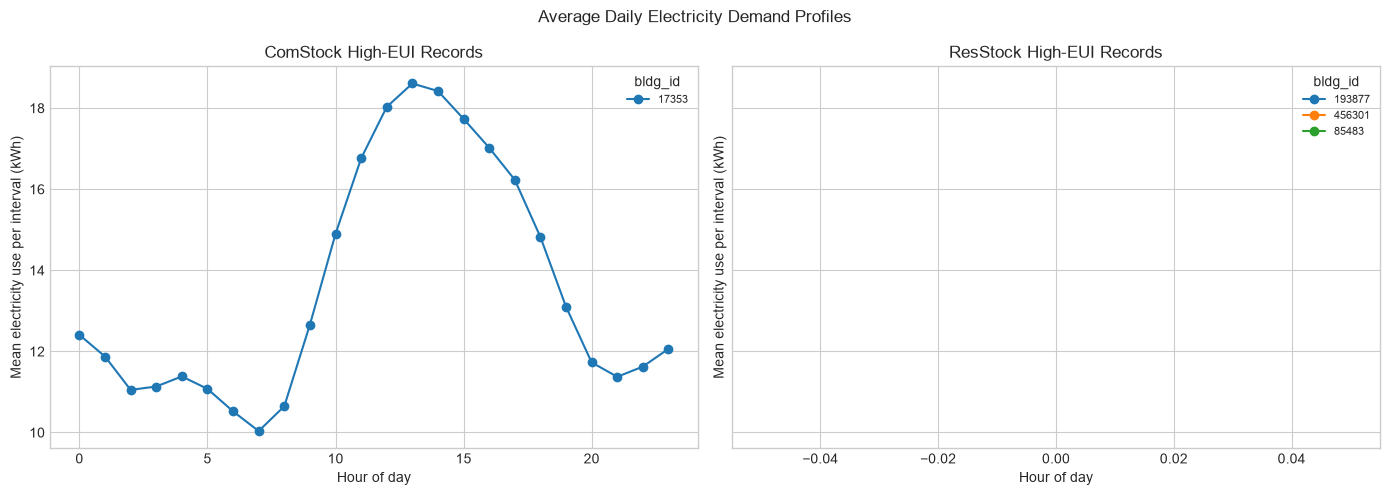

In [7]:
electricity_total_col = "out.electricity.total.energy_consumption"
if electricity_total_col not in ts_df.columns:
    total_cols = [col for col in energy_cols if ".total." in col]
    raise KeyError(f"Expected {electricity_total_col} in time-series data. Available total columns: {total_cols}")

daily_profile = (
    ts_df.assign(hour=ts_df["timestamp"].dt.hour)
    .groupby(["stock", "bldg_id", "hour"], as_index=False)[electricity_total_col]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, stock_name in zip(axes, ["ComStock", "ResStock"]):
    subset = daily_profile[daily_profile["stock"] == stock_name]
    for building_id, frame in subset.groupby("bldg_id"):
        ax.plot(frame["hour"], frame[electricity_total_col], marker="o", linewidth=1.5, label=building_id)
    ax.set_title(f"{stock_name} High-EUI Records")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Mean electricity use per interval (kWh)")
    ax.legend(title="bldg_id", fontsize=8)
fig.suptitle("Average Daily Electricity Demand Profiles")
fig.tight_layout()
plt.show()

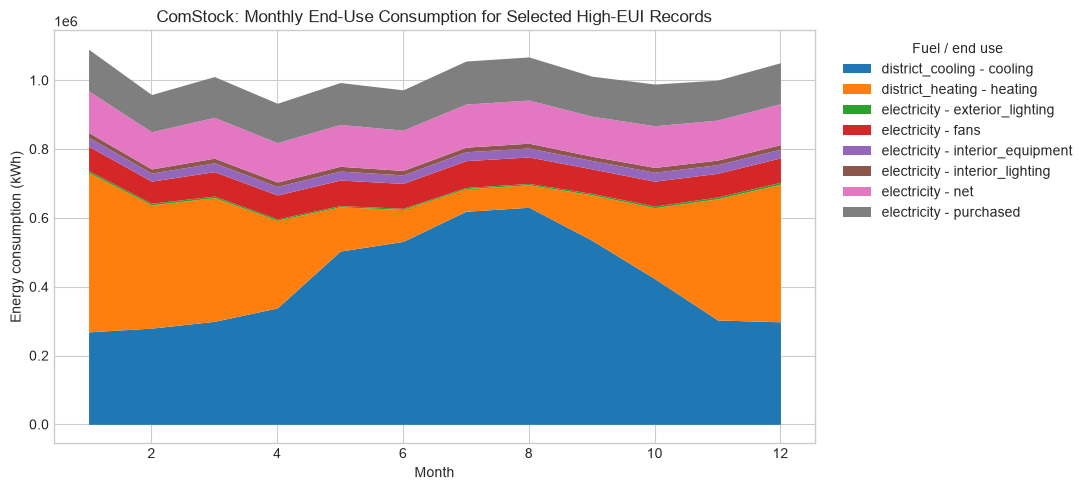

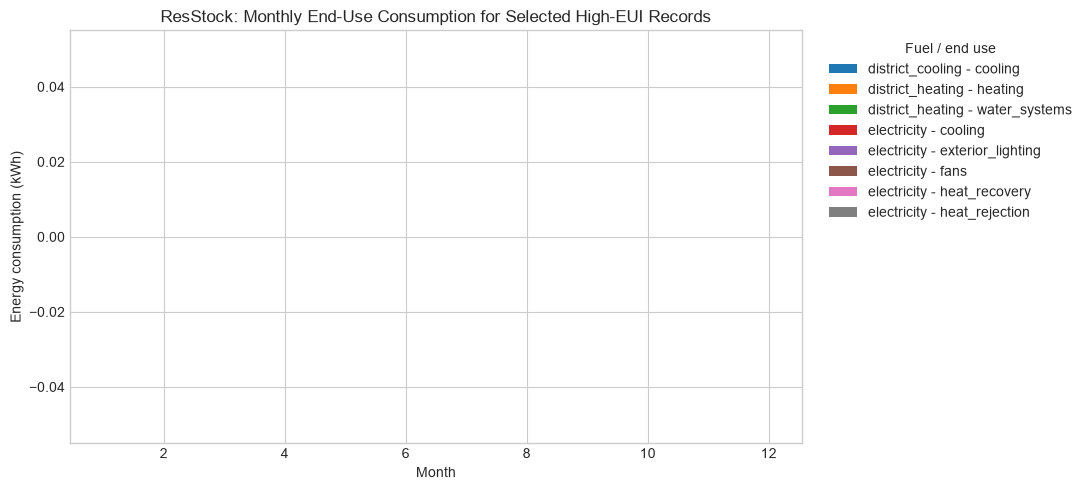

In [8]:
def parse_end_use_column(column: str) -> tuple[str, str] | None:
    match = re.fullmatch(r"out\.([^.]+)\.(.+)\.energy_consumption", column)
    if match is None:
        return None
    fuel, end_use = match.groups()
    if end_use == "total":
        return None
    return fuel, end_use


parsed_cols = {col: parse_end_use_column(col) for col in energy_cols}
end_use_cols = [col for col, parsed in parsed_cols.items() if parsed is not None]

monthly_long = ts_df[["stock", "bldg_id", "timestamp", *end_use_cols]].melt(
    id_vars=["stock", "bldg_id", "timestamp"],
    var_name="column",
    value_name="energy_kwh",
)
monthly_long["month"] = monthly_long["timestamp"].dt.month
monthly_long["fuel"] = monthly_long["column"].map(lambda col: parsed_cols[col][0])
monthly_long["end_use"] = monthly_long["column"].map(lambda col: parsed_cols[col][1])
monthly_long["fuel_end_use"] = monthly_long["fuel"] + " - " + monthly_long["end_use"]

monthly_end_use = monthly_long.groupby(["stock", "month", "fuel_end_use"], as_index=False)["energy_kwh"].sum()

for stock_name, frame in monthly_end_use.groupby("stock"):
    top_end_uses = frame.groupby("fuel_end_use")["energy_kwh"].sum().nlargest(8).index
    pivot = (
        frame[frame["fuel_end_use"].isin(top_end_uses)]
        .pivot_table(index="month", columns="fuel_end_use", values="energy_kwh", aggfunc="sum")
        .fillna(0)
        .sort_index()
    )
    pivot.plot(kind="area", stacked=True, figsize=(11, 5), linewidth=0)
    plt.title(f"{stock_name}: Monthly End-Use Consumption for Selected High-EUI Records")
    plt.xlabel("Month")
    plt.ylabel("Energy consumption (kWh)")
    plt.legend(title="Fuel / end use", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Recommend Measures

The recommendation logic below is deliberately transparent: it identifies each selected record's largest time-series end use and fuel balance, then maps those drivers to measure-package keywords available in the relevant stock dataset's upgrade lookup.

In [9]:
comstock_upgrades = comstock_download_processor.list_upgrades(comstock_dir)
resstock_upgrades = resstock_download_processor.list_upgrades(resstock_dir)


def matching_upgrades(upgrades: dict[str, str], keywords: list[str], limit: int = 4) -> str:
    matches = []
    for upgrade_id, name in upgrades.items():
        lowered = name.lower()
        if any(keyword.lower() in lowered for keyword in keywords):
            matches.append(f"{upgrade_id}: {name}")
    return "; ".join(matches[:limit]) if matches else "No direct package-name match found"


def recommendation_focus(top_end_use: str, electricity_share: float) -> tuple[str, list[str]]:
    lowered = top_end_use.lower()
    if "cool" in lowered:
        return "Cooling load reduction and high-efficiency HVAC", ["cool", "rtu", "heat pump", "economizer"]
    if "heat" in lowered or electricity_share < 0.45:
        return "Heating fuel reduction, electrification, and envelope improvements", [
            "heat pump",
            "envelope",
            "insulation",
            "air seal",
        ]
    if "light" in lowered:
        return "Lighting power and controls", ["lighting", "occupancy", "control"]
    if "water" in lowered:
        return "Domestic hot water efficiency", ["water heater", "heat pump water", "dhw"]
    if electricity_share >= 0.70:
        return "Electric peak and plug/process load management", ["controls", "plug", "equipment", "demand"]
    return "Whole-building efficiency package review", ["package", "efficiency", "upgrade"]


annual_selected = selected.set_index(["stock", "bldg_id"])
end_use_by_building = (
    monthly_long.groupby(["stock", "bldg_id", "fuel_end_use"], as_index=False)["energy_kwh"].sum()
    .sort_values(["stock", "bldg_id", "energy_kwh"], ascending=[True, True, False])
)

recommendations = []
for (stock_name, building_id), group in end_use_by_building.groupby(["stock", "bldg_id"]):
    top_end_use = group.iloc[0]["fuel_end_use"]
    row = annual_selected.loc[(stock_name, building_id)]
    if isinstance(row, pd.DataFrame):
        row = row.iloc[0]
    electricity = pd.to_numeric(row.get("out.electricity.total.energy_consumption..kwh", 0), errors="coerce")
    natural_gas = pd.to_numeric(row.get("out.natural_gas.total.energy_consumption..kwh", 0), errors="coerce")
    electricity = 0 if pd.isna(electricity) else float(electricity)
    natural_gas = 0 if pd.isna(natural_gas) else float(natural_gas)
    electricity_share = electricity / max(electricity + natural_gas, 1)
    focus, keywords = recommendation_focus(top_end_use, electricity_share)
    upgrades = comstock_upgrades if stock_name == "ComStock" else resstock_upgrades
    recommendations.append(
        {
            "stock": stock_name,
            "bldg_id": building_id,
            "category": row["building_category"],
            "site_eui_kwh_per_ft2": row[EUI_COL],
            "dominant_time_series_end_use": top_end_use,
            "electricity_share_of_elec_plus_gas": round(electricity_share, 2),
            "recommended_measure_focus": focus,
            "matching_available_upgrade_packages": matching_upgrades(upgrades, keywords),
        }
    )

recommendations_df = pd.DataFrame(recommendations).sort_values(["stock", "site_eui_kwh_per_ft2"], ascending=[True, False])
display(recommendations_df)

/var/folders/61/mn_btkk129jgbmwtsltjljzw0000gr/T/ipykernel_70716/480691624.py:43: PerformanceWarning: indexing past lexsort depth may impact performance.
  row = annual_selected.loc[(stock_name, building_id)]
/var/folders/61/mn_btkk129jgbmwtsltjljzw0000gr/T/ipykernel_70716/480691624.py:43: PerformanceWarning: indexing past lexsort depth may impact performance.
  row = annual_selected.loc[(stock_name, building_id)]


,stock,bldg_id,category,site_eui_kwh_per_ft2,dominant_time_series_end_use,electricity_share_of_elec_plus_gas,recommended_measure_focus,matching_available_upgrade_packages
0,ComStock,17353,LargeOffice,67.945290,district_cooling - cooling,1.00,Cooling load reduction and high-efficiency HVAC,"1: Variable Speed HP RTU, Electric Backup; 2: ..."
2,ResStock,456301,Multi-Family with 2 - 4 Units,42.224988,district_cooling - cooling,0.21,Cooling load reduction and high-efficiency HVAC,4: Typical Cold Climate Ducted Air Source Heat...
1,ResStock,193877,Multi-Family with 5+ Units,37.942692,district_cooling - cooling,0.48,Cooling load reduction and high-efficiency HVAC,4: Typical Cold Climate Ducted Air Source Heat...
3,ResStock,85483,Multi-Family with 2 - 4 Units,36.422727,district_cooling - cooling,0.71,Cooling load reduction and high-efficiency HVAC,4: Typical Cold Climate Ducted Air Source Heat...


## Notes for Adapting

- Use `county_name="All"` for DC because the district is a single state-level search target in these releases.
- Increase the `head(n)` value in the high-EUI selection cell to download more time-series files.
- For a retrofit study, use `process_metadata_for_upgrades()` to compare the same records under specific upgrade packages before and after applying a measure.